In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install segyio opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 5.7 MB/s eta 0:00:00


In [3]:
%%writefile prediction.py
import torch
import numpy as np
import argparse
import segyio
from utils import prediction, cubing_prediction, write_data, create_out_dir
from shutil import copyfile
import os

parser = argparse.ArgumentParser(description='Prediction management')
parser.add_argument('--input', type=str, default=r'data/F3.npy',
                    help='Input cuboid path (.npy or .segy or .sgy)')
parser.add_argument('--iline', type=int, default=189,
                    help='inline')  # 189 or 77, If none of them work, please fill the trace export in the commercial software and then read it.
parser.add_argument('--xline', type=int, default=193,
                    help='crossline')  # 193 or 73,If none of them work, please fill the trace export in the commercial software and then read it.
parser.add_argument('--gamma', type=float, default=0.7, help='Must 0.5,0.6,0.7')
parser.add_argument('--infer_size', type=int, nargs='+', default=None,
                    help='If None, the whole seismic volume is input.'
                         'If not None, the volume will be cut in blocks according to infer_size then input.'
                         'Shape = (tline,xline,iline) or (tline,iline,xline), must be divisible by 16')
parser.add_argument('--output_dir', type=str, default='output', help='Output dir')
parser.add_argument('--save_fault_cuboid', type=bool, default=False, help='')
args = parser.parse_args()

device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')

if __name__ == '__main__':
    assert args.gamma == 0.5 or args.gamma == 0.6 or args.gamma == 0.7
    assert args.input[-3:] == 'npy' or args.input[-4:] == 'segy' or args.input[-3:] == 'sgy'
    if args.infer_size != None:
        assert args.infer_size[0] % 16 == 0 and args.infer_size[1] % 16 == 0 and args.infer_size[2] % 16 == 0
    if args.gamma == 0.5:
        model = torch.jit.load('network/FaultNet_Gamma0.5.pt').to(device)
    elif args.gamma == 0.6:
        model = torch.jit.load('network/FaultNet_Gamma0.6.pt').to(device)
    else:
        model = torch.jit.load('network/FaultNet_Gamma0.7.pt').to(device)

    if device.type != 'cpu': model = model.half()

    if args.input[-3:] == 'npy':
        data = np.load(args.input).transpose((2, 0, 1))  # Shape = (tline,xline,iline) or (tline,iline,xline),
    else:
        data = segyio.open(args.input, iline=args.iline, xline=args.xline)
        data = segyio.cube(data).transpose((2, 0, 1))  # Shape = (tline,xline,iline) or (tline,iline,xline),
    if args.infer_size == None:
        infer_size = data.shape
    else:
        infer_size = args.infer_size
    print('Load data successful.')
    print('Infer on', device)
    print(f'Data size is {tuple(data.shape)}, infer size is {infer_size}.')

    create_out_dir(args.output_dir, args.input)
    if args.infer_size == None:
        output = prediction(model, data, device)
    else:
        output = cubing_prediction(model, data, device, args.infer_size)
    print('Inference complete. Save results...')
    if args.save_fault_cuboid:
        if args.input[-3:] == 'npy':
            np.save(
                os.path.join(args.output_dir, os.path.split(args.input)[-1],
                             os.path.split(args.input)[-1] + '_Fault.npy'),
                output.transpose((1, 2, 0)))
            print(f'.npy fault cuboid file save in {args.output_dir}. Next save iline slices')
        else:
            output_file = os.path.join(args.output_dir, os.path.split(args.input)[-1],
                                       os.path.split(args.input)[-1] + '_Fault.segy')
            output = output.transpose((1, 2, 0))
            copyfile(args.input, output_file)
            with segyio.open(output_file, mode="r+", iline=args.iline, xline=args.xline) as src:
                for i, iline in enumerate(src.ilines):
                    src.iline[iline] = output[:, i, :]
            print(f'.segy fault cuboid file save in {args.output_dir}. Next save iline slices')
            output = output.transpose((2, 0, 1))
    write_data(output, data, args.output_dir, args.input, axis=2)
    print(f'iline slices save in {args.output_dir}. Next save tline slices')
    write_data(output, data, args.output_dir, args.input, axis=0)
    print(f'tline slices save in {args.output_dir}. Next save xline slices')
    write_data(output, data, args.output_dir, args.input, axis=1)
    print(f'xline slices save in {args.output_dir}. Slices save complete')

Writing prediction.py


In [4]:
%%writefile utils.py
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2


def normalization(data):
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range


def normalization_tensor(data):
    _range = torch.max(data) - torch.min(data)
    return (data - torch.min(data)) / _range


def z_score(data):
    return (data - np.mean(data)) / np.std(data)


def cubing_prediction(model, data, device, infer_size):
    with torch.no_grad():
        ol = 1
        model.eval()
        n1, n2, n3 = infer_size
        input_tensor = torch.from_numpy(data)
        m1, m2, m3 = data.shape
        c1 = np.ceil((m1 + ol) / (n1 - ol)).astype(np.int)
        c2 = np.ceil((m2 + ol) / (n2 - ol)).astype(np.int)
        c3 = np.ceil((m3 + ol) / (n3 - ol)).astype(np.int)
        p1 = (n1 - ol) * c1 + ol
        p2 = (n2 - ol) * c2 + ol
        p3 = (n3 - ol) * c3 + ol
        gp = torch.zeros((p1, p2, p3)).float() + 0.5
        gy = np.zeros((p1, p2, p3), dtype=np.single)
        gp[:m1, :m2, :m3] = input_tensor
        if device.type != 'cpu': gp = gp.half()
        for k1 in range(c1):
            for k2 in range(c2):
                for k3 in range(c3):
                    b1 = k1 * n1 - k1 * ol
                    e1 = b1 + n1
                    b2 = k2 * n2 - k2 * ol
                    e2 = b2 + n2
                    b3 = k3 * n3 - k3 * ol
                    e3 = b3 + n3
                    gs = gp[b1:e1, b2:e2, b3:e3]
                    gs = normalization_tensor(gs[None, None, :, :, :]).to(device)
                    Y = model(gs).cpu().numpy()
                    gy[b1:e1, b2:e2, b3:e3] = gy[b1:e1, b2:e2, b3:e3] + Y[0, 0, :, :, :]
    return gy[:m1, :m2, :m3]


def prediction(model, data, device):
    model.eval()
    data = normalization(data)
    m1, m2, m3 = data.shape
    c1 = (np.ceil(m1 / 16) * 16).astype(np.int)
    c2 = (np.ceil(m2 / 16) * 16).astype(np.int)
    c3 = (np.ceil(m3 / 16) * 16).astype(np.int)
    input_tensor = np.zeros((c1, c2, c3), dtype=np.float32) + 0.5
    input_tensor[:m1, :m2, :m3] = data
    input_tensor = torch.from_numpy(input_tensor)[None, None, :, :, :].to(device)
    if device.type == 'cpu':
        input_tensor = input_tensor.float()
    else:
        input_tensor = input_tensor.half()
    with torch.no_grad():
        result = model(input_tensor).cpu().numpy()[0, 0, :m1, :m2, :m3]
    return result


def write_data(results, geo_cube, out_path, input_file, axis=0):
    file_name = os.path.split(input_file)[-1]
    geo_cube = normalization(geo_cube)
    assert axis == 0 or axis == 1 or axis == 2
    for i in range(geo_cube.shape[axis]):
        if axis == 0:
            result = results[i, :, :]
            geo = geo_cube[i, :, :]
        elif axis == 1:
            result = results[:, i, :]
            geo = geo_cube[:, i, :]
        else:
            result = results[:, :, i]
            geo = geo_cube[:, :, i]
        hm = plt.get_cmap('bone')(geo)[:, :, :-1]
        geo = plt.get_cmap('seismic')(geo)[:, :, :-1]
        logits = np.clip((result[:, :, None]), a_min=0, a_max=1)
        colormap = plt.get_cmap('jet')(logits[:, :, 0])[:, :, :-1]
        hm = np.where(logits > 0.5, colormap, hm)
        line = np.ones((geo.shape[0], 50, 3))
        result = np.concatenate((geo, line, hm), axis=1)
        result = (result * 255).astype(np.uint8)
        if axis == 0:
            cv2.imwrite(os.path.join(out_path, file_name, 'tline', f'{axis}_%05d_.png' % i),
                        cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
        if axis == 1:
            cv2.imwrite(os.path.join(out_path, file_name, 'xline', f'{axis}_%05d_.png' % i),
                        cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
        if axis == 2:
            cv2.imwrite(os.path.join(out_path, file_name, 'iline', f'{axis}_%05d_.png' % i),
                        cv2.cvtColor(result, cv2.COLOR_RGB2BGR))


def create_out_dir(output_dir, input_file):
    file_name = os.path.split(input_file)[-1]

    if not os.path.exists(output_dir):
        os.mkdir(output_dir)
        os.mkdir(os.path.join(output_dir, file_name))
        os.mkdir(os.path.join(output_dir, file_name, 'iline'))
        os.mkdir(os.path.join(output_dir, file_name, 'xline'))
        os.mkdir(os.path.join(output_dir, file_name, 'tline'))

    if not os.path.exists(os.path.join(output_dir, file_name)):
        os.mkdir(os.path.join(output_dir, file_name))

    if not os.path.exists(os.path.join(output_dir, file_name, 'iline')):
        os.mkdir(os.path.join(output_dir, file_name, 'iline'))

    if not os.path.exists(os.path.join(output_dir, file_name, 'xline')):
        os.mkdir(os.path.join(output_dir, file_name, 'xline'))

    if not os.path.exists(os.path.join(output_dir, file_name, 'tline')):
        os.mkdir(os.path.join(output_dir, file_name, 'tline'))


Writing utils.py


In [11]:
!sed -i 's/np.int/int/g' utils.py

In [12]:
!python prediction.py --input data/F3.npy --gamma 0.7

Load data successful.
Infer on cuda:0
Data size is (128, 512, 384), infer size is (128, 512, 384).
Inference complete. Save results...
iline slices save in output. Next save tline slices
tline slices save in output. Next save xline slices
xline slices save in output. Slices save complete


(np.float64(-0.5), np.float64(1073.5), np.float64(127.5), np.float64(-0.5))

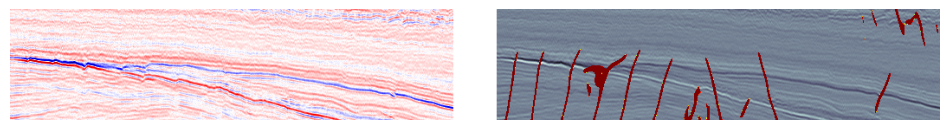

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/F3.npy/iline/2_00050_.png')

plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis('off')

(np.float64(-0.5), np.float64(817.5), np.float64(511.5), np.float64(-0.5))

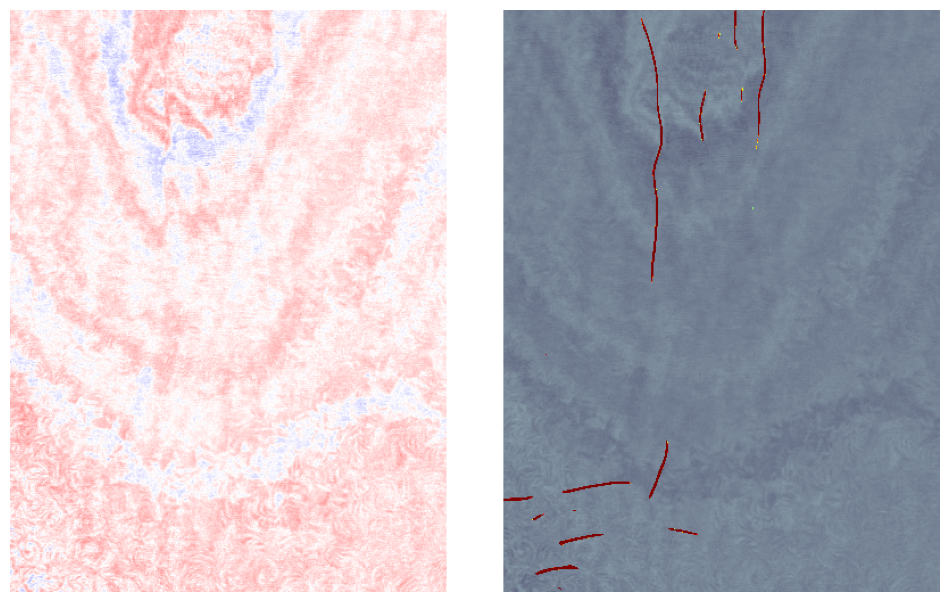

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/output/F3.npy/tline/0_00026_.png')

plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis('off')

(np.float64(-0.5), np.float64(817.5), np.float64(127.5), np.float64(-0.5))

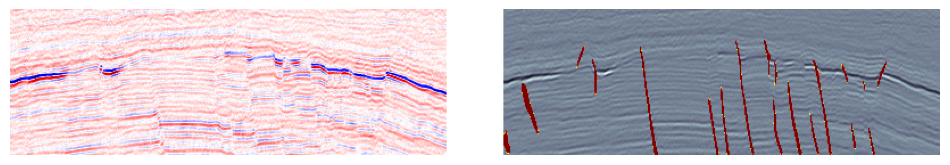

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/output/F3.npy/xline/1_00000_.png')

plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis('off')

In [24]:
!python prediction.py \
--input data/Kerry_full.npy \
--gamma 0.6 \
--infer_size 64 64 64

Load data successful.
Infer on cuda:0
Data size is (768, 176, 512), infer size is [64, 64, 64].
Inference complete. Save results...
iline slices save in output. Next save tline slices
tline slices save in output. Next save xline slices
xline slices save in output. Slices save complete


Total slices: 512
['2_00000_.png', '2_00001_.png', '2_00002_.png', '2_00003_.png', '2_00004_.png', '2_00005_.png', '2_00006_.png', '2_00007_.png', '2_00008_.png', '2_00009_.png']


(np.float64(-0.5), np.float64(401.5), np.float64(767.5), np.float64(-0.5))

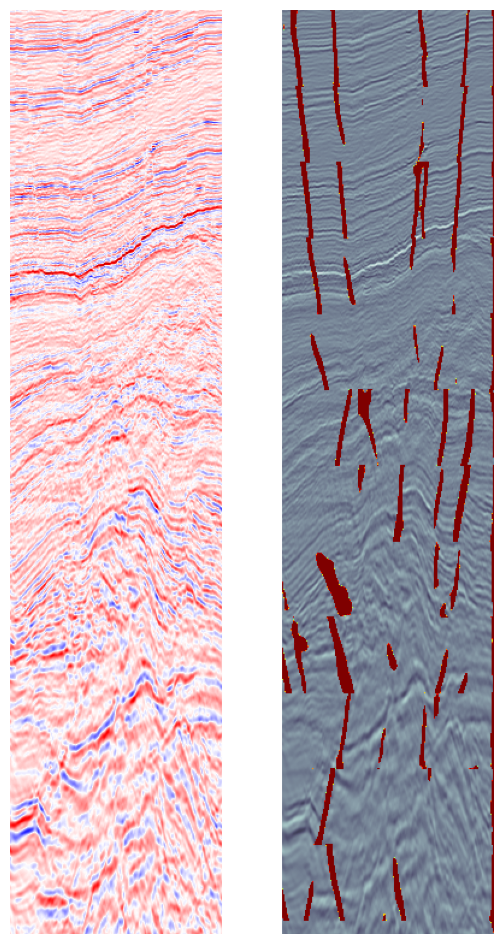

In [25]:
import os
from PIL import Image
import matplotlib.pyplot as plt

path = 'output/Kerry_full.npy/iline'

files = sorted(os.listdir(path))

print("Total slices:", len(files))
print(files[:10])

img = Image.open(os.path.join(path, files[100]))

plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis('off')

In [26]:
import ipywidgets as widgets
from PIL import Image
import matplotlib.pyplot as plt
import os

path = 'output/Kerry_full.npy/iline'
files = sorted(os.listdir(path))

def show_slice(i):
    img = Image.open(os.path.join(path, files[i]))

    plt.figure(figsize=(12,12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(files[i])
    plt.show()

widgets.interact(show_slice, i=(0, len(files)-1))

interactive(children=(IntSlider(value=255, description='i', max=511), Output()), _dom_classes=('widget-interac…

<function __main__.show_slice(i)>

In [27]:
!zip -r FaultNet_results.zip output/

  adding: output/ (stored 0%)
  adding: output/Kerry_full.npy/ (stored 0%)
  adding: output/Kerry_full.npy/xline/ (stored 0%)
  adding: output/Kerry_full.npy/xline/1_00133_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00046_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00109_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00004_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00040_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00116_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00006_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00063_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00013_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00152_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00102_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00041_.png (deflated 5%)
  adding: output/Kerry_full.npy/xline/1_00037_.png (deflated 5%)
  adding: output/Kerry_full.n

In [28]:
from google.colab import files
files.download("FaultNet_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>